# Analyse RH & Churn Employés — SQL + Power BI

**SQLite · SQL · Pandas · Matplotlib · Power BI · DAX**

---

Pour ce deuxième projet, j'ai voulu travailler sur une problématique que toutes
les entreprises rencontrent : pourquoi les employés partent-ils, et surtout,
est-ce qu'on peut l'anticiper avec les données ?

J'ai travaillé sur un dataset de 1 470 employés avec des informations sur leur
département, salaire, satisfaction, ancienneté et heures supplémentaires.
L'objectif était d'identifier les profils les plus à risque de quitter l'entreprise.

J'ai structuré le projet en deux parties. D'abord une analyse SQL complète —
j'ai chargé les données dans une vraie base de données SQLite et j'ai écrit
des requêtes de plus en plus avancées pour extraire les insights : du simple
GROUP BY jusqu'aux CTEs et Window Functions. Ensuite, j'ai exporté les résultats
vers Power BI pour construire un dashboard interactif avec des mesures DAX,
des filtres par département, genre et overtime — le genre de rendu qu'on
présente à un RH ou un directeur qui ne lit pas du code.

**Ce que ce projet couvre :**

- Créer et interroger une base de données SQL depuis Python
- Requêtes SQL basiques : SELECT, GROUP BY, ORDER BY, CASE WHEN
- Requêtes SQL avancées : CTE (WITH), Window Functions, JOIN
- Dashboard Power BI interactif avec mesures DAX
- Recommandations RH concrètes basées sur les données
- 

## Étape 1 — Imports et configuration

In [6]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Librairies importées ✓")

Librairies importées ✓


## Étape 2 — Chargement et création de la base SQL

In [7]:
# Charger le CSV
df = pd.read_csv('hr_data.csv')
print(f"Dataset : {df.shape[0]} employés, {df.shape[1]} colonnes")
print(f"Taux de churn : {(df['Attrition']=='Yes').mean()*100:.1f}%")
df.head()

Dataset : 1470 employés, 19 colonnes
Taux de churn : 15.5%


,EmployeeID,Age,Gender,Department,JobRole,EducationField,Education,MonthlyIncome,JobLevel,YearsAtCompany,YearsInCurrentRole,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,PerformanceRating,OverTime,BusinessTravel,DistanceFromHome,Attrition
0,EMP0001,20,Female,Research & Development,Manager,Medical,1,8125,2,15,5,3,4,3,3,No,Travel_Rarely,12,Yes
1,EMP0002,52,Male,Human Resources,Human Resources,Marketing,2,9720,3,11,10,1,1,3,3,Yes,Non-Travel,9,No
2,EMP0003,29,Female,Research & Development,Research Scientist,Technical Degree,3,8474,5,1,0,2,3,3,3,No,Travel_Frequently,22,No
3,EMP0004,41,Male,Research & Development,Healthcare Representative,Medical,2,10798,2,2,1,1,3,2,4,Yes,Travel_Rarely,4,Yes
4,EMP0005,22,Male,Sales,Sales Representative,Life Sciences,3,6824,3,8,6,2,1,3,3,No,Non-Travel,13,No


In [8]:
# Créer la base de données SQLite
conn = sqlite3.connect('hr_database.db')

# Charger le DataFrame dans la base SQL
df.to_sql('employees', conn, if_exists='replace', index=False)

# Vérifier
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables disponibles :", tables['name'].tolist())
print("Colonnes :", df.columns.tolist())

Tables disponibles : ['employees']
Colonnes : ['EmployeeID', 'Age', 'Gender', 'Department', 'JobRole', 'EducationField', 'Education', 'MonthlyIncome', 'JobLevel', 'YearsAtCompany', 'YearsInCurrentRole', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'PerformanceRating', 'OverTime', 'BusinessTravel', 'DistanceFromHome', 'Attrition']


## Étape 3 — Requêtes SQL de base

> **Pourquoi SQL plutôt que Pandas ?**
> SQL c'est le langage universel des bases de données. Dans une vraie entreprise, les données sont souvent dans des bases SQL (PostgreSQL, MySQL, SQL Server). Savoir écrire des requêtes SQL est une compétence indispensable pour tout data analyst.

In [9]:
# Fonction utilitaire pour afficher les résultats proprement
def query(sql, conn=conn):
    return pd.read_sql_query(sql, conn)

In [10]:
# Q1 — Répartition des employés par département
query("""
SELECT Department,
       COUNT(*) AS nb_employes,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 1) AS pourcentage
FROM employees
GROUP BY Department
ORDER BY nb_employes DESC
""")

,Department,nb_employes,pourcentage
0,Research & Development,856,58.2
1,Sales,461,31.4
2,Human Resources,153,10.4


In [11]:
# Q2 — Salaires min, max, moyen par département
query("""
SELECT Department,
       ROUND(AVG(MonthlyIncome), 0) AS salaire_moyen,
       ROUND(MIN(MonthlyIncome), 0) AS salaire_min,
       ROUND(MAX(MonthlyIncome), 0) AS salaire_max
FROM employees
GROUP BY Department
ORDER BY salaire_moyen DESC
""")

,Department,salaire_moyen,salaire_min,salaire_max
0,Research & Development,9582.0,5389.0,13063.0
1,Sales,9132.0,5476.0,12808.0
2,Human Resources,8471.0,5592.0,11250.0


In [12]:
# Q3 — Taux de churn par département
# CASE WHEN = équivalent du if/else en SQL
query("""
SELECT Department,
       COUNT(*) AS total,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS departs,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS taux_churn_pct
FROM employees
GROUP BY Department
ORDER BY taux_churn_pct DESC
""")

,Department,total,departs,taux_churn_pct
0,Sales,461,78,16.9
1,Research & Development,856,129,15.1
2,Human Resources,153,21,13.7


In [13]:
# Q4 — Impact de l'overtime sur le churn
query("""
SELECT OverTime,
       COUNT(*) AS total,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS departs,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS taux_churn_pct
FROM employees
GROUP BY OverTime
ORDER BY taux_churn_pct DESC
""")

,OverTime,total,departs,taux_churn_pct
0,Yes,416,99,23.8
1,No,1054,129,12.2


## Étape 4 — Requêtes SQL avancées

### CTE (Common Table Expression)
Une CTE c'est une "requête temporaire" qu'on nomme avec `WITH nom AS (...)`.
Ça permet d'écrire des requêtes complexes de façon lisible, en les découpant en étapes.

### Window Functions
Les Window Functions calculent une valeur **en gardant toutes les lignes** (contrairement à GROUP BY qui réduit). `RANK() OVER (PARTITION BY dept ORDER BY salaire DESC)` = rang du salaire dans chaque département.

In [14]:
# Q5 — CTE : comparer le profil des partants vs restants
query("""
WITH churned AS (
    SELECT 'Partent' AS statut,
           ROUND(AVG(Age), 1) AS age_moyen,
           ROUND(AVG(MonthlyIncome), 0) AS salaire_moyen,
           ROUND(AVG(YearsAtCompany), 1) AS anciennete_moy,
           ROUND(AVG(JobSatisfaction), 2) AS satisfaction_moy
    FROM employees WHERE Attrition = 'Yes'
),
retained AS (
    SELECT 'Restent' AS statut,
           ROUND(AVG(Age), 1) AS age_moyen,
           ROUND(AVG(MonthlyIncome), 0) AS salaire_moyen,
           ROUND(AVG(YearsAtCompany), 1) AS anciennete_moy,
           ROUND(AVG(JobSatisfaction), 2) AS satisfaction_moy
    FROM employees WHERE Attrition = 'No'
)
SELECT * FROM churned
UNION ALL
SELECT * FROM retained
""")

,statut,age_moyen,salaire_moyen,anciennete_moy,satisfaction_moy
0,Partent,38.1,9290.0,6.0,2.04
1,Restent,39.0,9332.0,6.6,2.58


In [15]:
# Q6 — Window Function : Top 3 salaires par département
query("""
SELECT Department, JobRole, MonthlyIncome, rang_dept
FROM (
    SELECT Department,
           JobRole,
           MonthlyIncome,
           RANK() OVER (PARTITION BY Department ORDER BY MonthlyIncome DESC) AS rang_dept
    FROM employees
) ranked
WHERE rang_dept <= 3
ORDER BY Department, rang_dept
""")

,Department,JobRole,MonthlyIncome,rang_dept
0,Human Resources,Human Resources,11250,1
1,Human Resources,Manager,11155,2
2,Human Resources,Human Resources,11019,3
3,Research & Development,Research Director,13063,1
4,Research & Development,Research Director,12787,2
5,Research & Development,Research Director,12781,3
6,Sales,Manager,12808,1
7,Sales,Sales Representative,12703,2
8,Sales,Sales Executive,12398,3


In [16]:
# Q7 — CASE WHEN : satisfaction et son impact sur le churn
query("""
SELECT
    CASE JobSatisfaction
        WHEN 1 THEN '1 - Faible'
        WHEN 2 THEN '2 - Moyen'
        WHEN 3 THEN '3 - Bon'
        WHEN 4 THEN '4 - Excellent'
    END AS niveau_satisfaction,
    COUNT(*) AS nb_employes,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM employees), 1) AS pct_effectif,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 1) AS taux_churn_pct
FROM employees
GROUP BY JobSatisfaction
ORDER BY JobSatisfaction
""")

,niveau_satisfaction,nb_employes,pct_effectif,taux_churn_pct
0,1 - Faible,312,21.2,33.0
1,2 - Moyen,427,29.0,11.2
2,3 - Bon,420,28.6,10.2
3,4 - Excellent,311,21.2,10.9


In [19]:
# Créer la table departments
import pandas as pd

dept_data = pd.DataFrame({
    'DepartmentID':   [1, 2, 3],
    'DepartmentName': ['Sales', 'Research & Development', 'Human Resources'],
    'Manager':        ['Alice Martin', 'Bob Chen', 'Claire Dupont'],
    'Budget':         [500000, 800000, 200000]
})

dept_data.to_sql('departments', conn, if_exists='replace', index=False)

# Vérifier que les deux tables existent
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables disponibles :", tables['name'].tolist())

Tables disponibles : ['employees', 'departments']


In [20]:
# Q8 — JOIN : combiner la table employees avec la table departments
query("""
SELECT d.DepartmentName,
       d.Manager,
       d.Budget,
       COUNT(e.EmployeeID) AS nb_employes,
       ROUND(d.Budget * 1.0 / COUNT(e.EmployeeID), 0) AS budget_par_employe,
       ROUND(AVG(e.MonthlyIncome), 0) AS salaire_moyen
FROM departments d
JOIN employees e ON d.DepartmentName = e.Department
GROUP BY d.DepartmentName
ORDER BY nb_employes DESC
""")

,DepartmentName,Manager,Budget,nb_employes,budget_par_employe,salaire_moyen
0,Research & Development,Bob Chen,800000,856,935.0,9582.0
1,Sales,Alice Martin,500000,461,1085.0,9132.0
2,Human Resources,Claire Dupont,200000,153,1307.0,8471.0


## Étape 5 — Dashboard de visualisation

In [21]:
# Récupérer les données pour les graphiques
q_dept_churn = query("""
    SELECT Department,
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS churn
    FROM employees GROUP BY Department ORDER BY churn DESC""")

q_sat_churn = query("""
    SELECT JobSatisfaction,
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS churn
    FROM employees GROUP BY JobSatisfaction ORDER BY JobSatisfaction""")

q_overtime = query("""
    SELECT OverTime,
           SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS departs,
           SUM(CASE WHEN Attrition='No'  THEN 1 ELSE 0 END) AS restes
    FROM employees GROUP BY OverTime""")

q_joblevel = query("""
    SELECT JobLevel,
           ROUND(AVG(MonthlyIncome),0) AS salaire_moyen,
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS churn
    FROM employees GROUP BY JobLevel ORDER BY JobLevel""")

print("Données récupérées ✓")

Données récupérées ✓


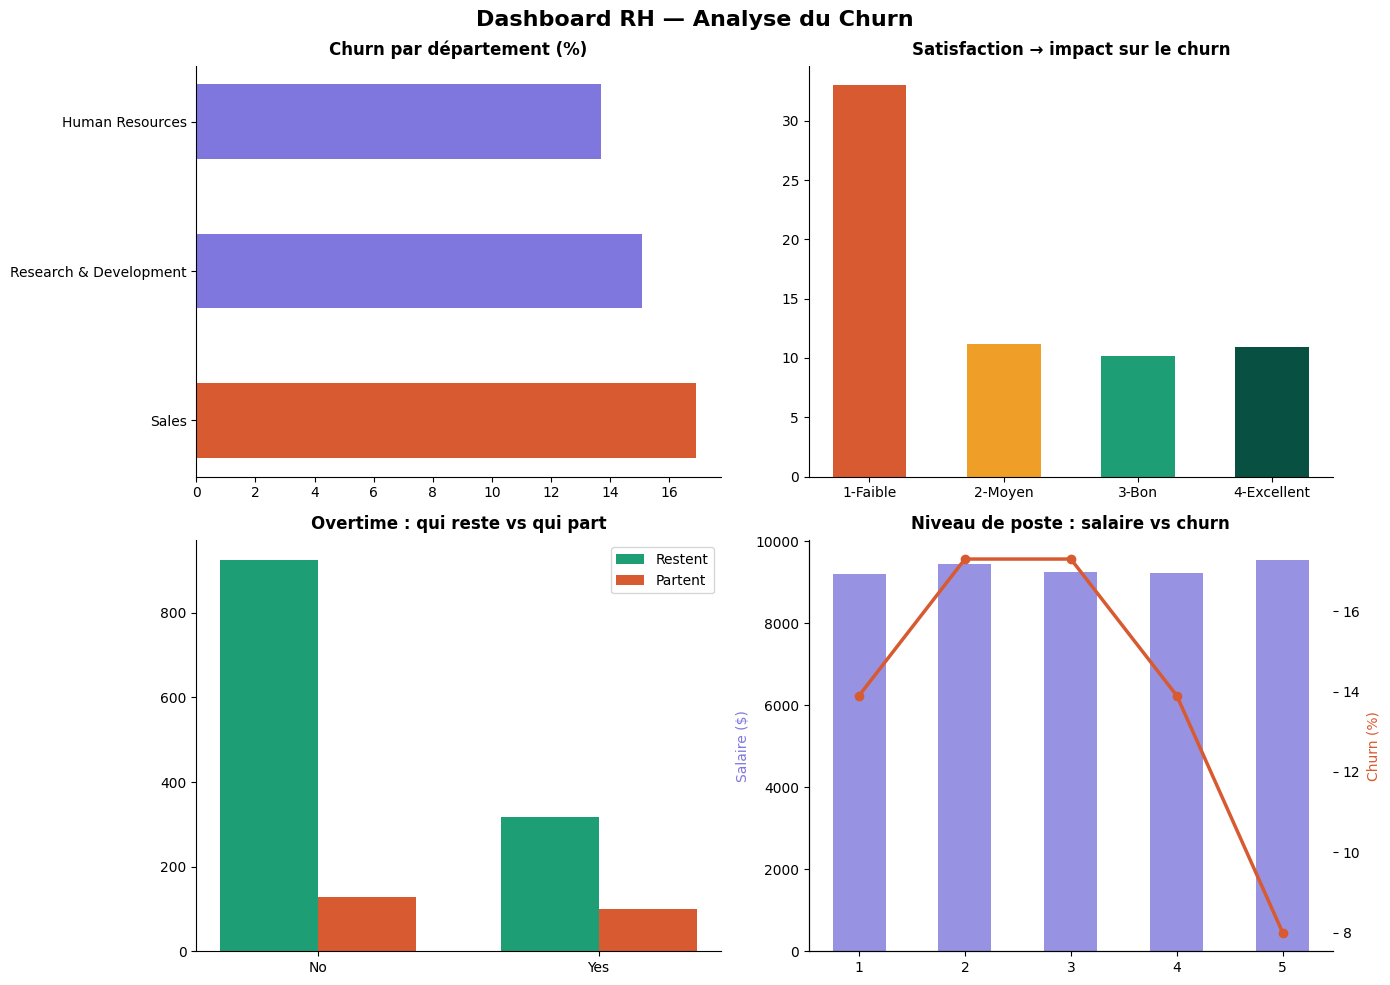

Dashboard sauvegardé ✓


In [22]:
# Créer le dashboard
C_PURPLE = '#7F77DD'
C_TEAL   = '#1D9E75'
C_CORAL  = '#D85A30'
C_AMBER  = '#EF9F27'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard RH — Analyse du Churn', fontsize=16, fontweight='bold')

def fmt(ax, title):
    ax.set_title(title, fontweight='bold', pad=8)
    for s in ['top','right']: ax.spines[s].set_visible(False)

# 1. Churn par département
ax = axes[0,0]
colors = [C_CORAL if v == q_dept_churn['churn'].max() else C_PURPLE for v in q_dept_churn['churn']]
ax.barh(q_dept_churn['Department'], q_dept_churn['churn'], color=colors, height=0.5)
fmt(ax, 'Churn par département (%)')

# 2. Satisfaction → Churn
ax = axes[0,1]
labels = ['1-Faible','2-Moyen','3-Bon','4-Excellent']
ax.bar(labels, q_sat_churn['churn'], color=[C_CORAL,C_AMBER,C_TEAL,'#085041'], width=0.55)
fmt(ax, 'Satisfaction → impact sur le churn')

# 3. Overtime
ax = axes[1,0]
x = np.arange(len(q_overtime))
ax.bar(x-0.175, q_overtime['restes'],  0.35, label='Restent', color=C_TEAL)
ax.bar(x+0.175, q_overtime['departs'], 0.35, label='Partent', color=C_CORAL)
ax.set_xticks(x); ax.set_xticklabels(q_overtime['OverTime'].tolist())
ax.legend(); fmt(ax, 'Overtime : qui reste vs qui part')

# 4. Niveau de poste
ax   = axes[1,1]
axb  = ax.twinx()
ax.bar(q_joblevel['JobLevel'].astype(str), q_joblevel['salaire_moyen'], color=C_PURPLE, alpha=0.8, width=0.5)
axb.plot(q_joblevel['JobLevel'].astype(str), q_joblevel['churn'], 'o-', color=C_CORAL, lw=2.5)
ax.set_ylabel('Salaire ($)', color=C_PURPLE)
axb.set_ylabel('Churn (%)', color=C_CORAL)
fmt(ax, 'Niveau de poste : salaire vs churn')

plt.tight_layout()
plt.savefig('hr_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard sauvegardé ✓")

## Étape 6 — Insights & Recommandations

In [1]:
# Résumé final avec les chiffres clés
total   = query("SELECT COUNT(*) AS n FROM employees").iloc[0,0]
departs = query("SELECT COUNT(*) AS n FROM employees WHERE Attrition='Yes'").iloc[0,0]
ot_yes  = query("SELECT ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS c FROM employees WHERE OverTime='Yes'").iloc[0,0]
ot_no   = query("SELECT ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS c FROM employees WHERE OverTime='No'").iloc[0,0]
sat1    = query("SELECT ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1.0 ELSE 0 END)/COUNT(*)*100,1) AS c FROM employees WHERE JobSatisfaction=1").iloc[0,0]

print("=" * 55)
print("INSIGHTS CLÉS")
print(f"Churn global              : {departs/total*100:.1f}% ({departs}/{total})")
print(f"Churn avec overtime       : {ot_yes}%")
print(f"Churn sans overtime       : {ot_no}%")
print(f"Churn satisfaction faible : {sat1}%")
print()
print("RECOMMANDATIONS")
print("1. Réduire l'overtime → multiplie le churn par 2")
print("2. Agir sur la satisfaction faible → 33% de churn")
print("3. Focus Sales (département le plus à risque)")
print("4. Programme rétention 25-34 ans (tranche la plus mobile)")

conn.close()

NameError: name 'query' is not defined

## Conclusion

Ce projet démontre une analyse data complète avec SQL :

- **SQLite** : créer et interroger une vraie base de données
- **SQL basique** : SELECT, GROUP BY, ORDER BY, CASE WHEN
- **SQL avancé** : CTE (WITH), Window Functions (RANK, OVER, PARTITION BY), JOIN
- **Dashboard** : 8 graphiques organisés, storytelling visuel
- **Recommandations** : actions RH concrètes basées sur les données

**Stack :** Python · SQLite · Pandas · Matplotlib · Jupyter Notebook
